# Trabajo Practico 1 - Continual Learning

Notebook de orquestacion para las etapas 4.1, 4.2, 4.3.1 y 4.3.2.

In [1]:
from pathlib import Path
import math
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader

sys.path.append(str(Path.cwd() / "src"))

from tp1_cl import (
    CIFAR10_CLASSES,
    ContrastiveTaskDataset,
    LabelMapper,
    ReservoirReplayBuffer,
    SeqCIFAR10Builder,
    TaskConfig,
    TransformConfig,
    TwoCropTransform,
    build_cifar_resnet,
    build_transforms,
    ensure_checkpoint_dir,
    load_checkpoint,
    load_config,
    save_checkpoint,
    set_seed,
    train_ewc_method,
    train_linear_head,
    train_naive_finetuning_method,
    train_lwf_method,
    train_co2l_method,
    train_er_ace_method,
    train_supcon,
)
from tp1_cl.models import SupConLoss, SupConNetwork
from tp1_cl.viz import (
    plot_cl_metrics,
    plot_embedding_snapshots,
    plot_linear_history,
    plot_supcon_loss,
)

cfg = load_config("configs/cifar10.yaml")
set_seed(int(cfg.training.seed))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ckpt_dir = ensure_checkpoint_dir(cfg.outputs.checkpoints)

def ckpt(name: str) -> Path:
    return ckpt_dir / name


Using device: cuda


## 4.1 Preparacion del dataset

In [2]:
num_workers = int(cfg.training.num_workers) if torch.cuda.is_available() else min(4, int(cfg.training.num_workers))
dataloader_kwargs = {
    "num_workers": num_workers,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": num_workers > 0,
}
if num_workers > 0:
    dataloader_kwargs["prefetch_factor"] = int(cfg.training.dataloader.prefetch_factor)

transform_cfg = TransformConfig(
    mean=tuple(cfg.transforms.mean),
    std=tuple(cfg.transforms.std),
    crop_size=int(cfg.transforms.crop_size),
    crop_scale=tuple(cfg.transforms.crop_scale),
    hflip_prob=float(cfg.transforms.hflip_prob),
    color_jitter_values=tuple(cfg.transforms.color_jitter_values),
    color_jitter_prob=float(cfg.transforms.color_jitter_prob),
    grayscale_prob=float(cfg.transforms.grayscale_prob),
)
eval_transform, supcon_train_transform = build_transforms(transform_cfg)

task_cfg = TaskConfig(
    n_tasks=int(cfg.data.n_tasks),
    classes_per_task=int(cfg.data.classes_per_task),
    class_order=list(cfg.data.class_order),
    shuffle_class_order=False,
    seed=int(cfg.training.seed),
)
seq_builder = SeqCIFAR10Builder(root=cfg.data.root, config=task_cfg)

task_train_loaders, task_test_loaders = seq_builder.build_task_loaders(
    batch_size=int(cfg.training.batch_size),
    transform=eval_transform,
    train_shuffle=True,
    num_workers=num_workers,
    loader_kwargs=dataloader_kwargs,
)

print("4.1 | Seq-CIFAR-10 split summary")
for row in seq_builder.summary_rows():
    print(
        f"Task {row['task_id']}: classes={row['class_names']} | train={row['n_train']} | test={row['n_test']}"
    )

replay_buffer = ReservoirReplayBuffer(capacity=int(cfg.data.buffer_size), seed=int(cfg.training.seed))
demo_images, demo_labels = next(iter(task_train_loaders[0]))
replay_buffer.add(demo_images, demo_labels)
sample_images, sample_labels = replay_buffer.sample(batch_size=16)
print(
    f"Replay buffer size={len(replay_buffer)} / {int(cfg.data.buffer_size)} | sample={sample_images.shape}, labels={sample_labels.shape}"
)


4.1 | Seq-CIFAR-10 split summary
Task 0: classes=['airplane', 'automobile'] | train=10000 | test=2000
Task 1: classes=['bird', 'cat'] | train=10000 | test=2000
Task 2: classes=['deer', 'dog'] | train=10000 | test=2000
Task 3: classes=['frog', 'horse'] | train=10000 | test=2000
Task 4: classes=['ship', 'truck'] | train=10000 | test=2000
Replay buffer size=200 / 200 | sample=torch.Size([16, 3, 32, 32]), labels=torch.Size([16])


## 4.2 Pre-entrenamiento SupCon

Loaded checkpoint: outputs/checkpoints/task0_supcon.pt


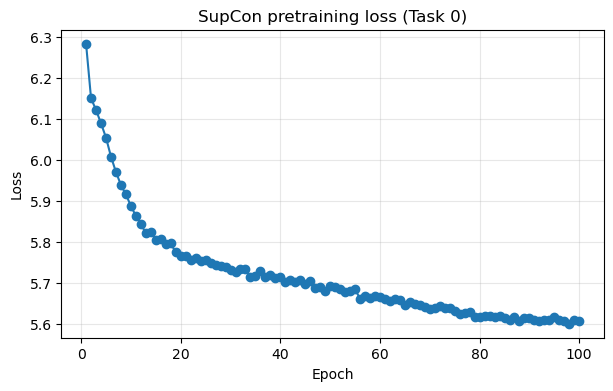

/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

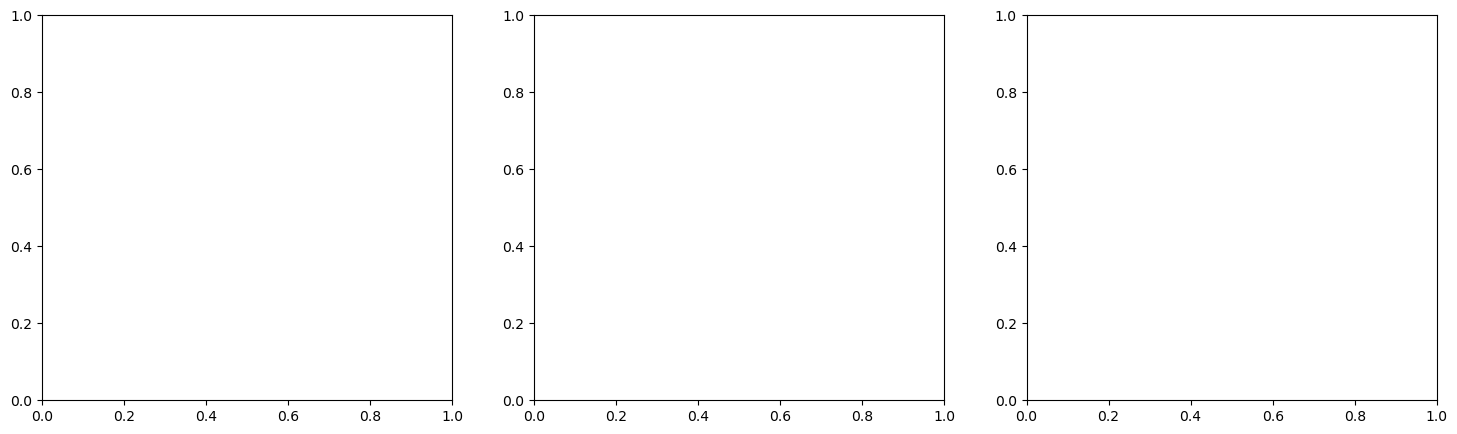

In [3]:
task0_classes = seq_builder.task_classes[0]
task0_class_names = [CIFAR10_CLASSES[c] for c in task0_classes]

task0_train_raw = seq_builder.get_task_dataset(task_id=0, train=True, transform=None)
task0_contrastive_ds = ContrastiveTaskDataset(
    task_dataset=task0_train_raw,
    two_crop_transform=TwoCropTransform(supcon_train_transform),
)
task0_contrastive_loader = DataLoader(
    task0_contrastive_ds,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    drop_last=True,
    **dataloader_kwargs,
)

task0_eval_loader = DataLoader(
    seq_builder.get_task_dataset(task_id=0, train=False, transform=eval_transform),
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

backbone, feat_dim = build_cifar_resnet(model_name="resnet18")
supcon_model = SupConNetwork(
    backbone=backbone,
    feat_dim=feat_dim,
    proj_dim=int(cfg.supcon.proj_dim),
).to(device)
supcon_criterion = SupConLoss(
    temperature=float(cfg.supcon.temperature),
    base_temperature=float(cfg.supcon.base_temperature),
)
supcon_optimizer = torch.optim.SGD(
    supcon_model.parameters(),
    lr=float(cfg.supcon.lr),
    momentum=float(cfg.supcon.momentum),
    weight_decay=float(cfg.supcon.weight_decay),
)

supcon_epochs = int(cfg.supcon.epochs)
warmup_epochs = int(cfg.supcon.warmup_epochs)

def supcon_lr_lambda(epoch: int) -> float:
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(max(1, warmup_epochs))
    if supcon_epochs == warmup_epochs:
        return 1.0
    progress = float(epoch - warmup_epochs) / float(supcon_epochs - warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

supcon_scheduler = torch.optim.lr_scheduler.LambdaLR(
    supcon_optimizer, lr_lambda=supcon_lr_lambda
)

snapshot_epochs = {max(1, supcon_epochs // 2): "mitad", supcon_epochs: "final"}
supcon_ckpt = ckpt("task0_supcon.pt")

if supcon_ckpt.exists():
    payload = load_checkpoint(supcon_ckpt, map_location=device)
    supcon_model.load_state_dict(payload["model"])
    supcon_losses = payload["losses"]
    embedding_snapshots = payload["snapshots"]
    print(f"Loaded checkpoint: {supcon_ckpt}")
else:
    supcon_losses, embedding_snapshots = train_supcon(
        model=supcon_model,
        train_loader=task0_contrastive_loader,
        eval_loader_for_snapshots=task0_eval_loader,
        criterion=supcon_criterion,
        optimizer=supcon_optimizer,
        device=device,
        epochs=supcon_epochs,
        snapshot_epochs=snapshot_epochs,
        scheduler=supcon_scheduler,
    )
    save_checkpoint(
        supcon_ckpt,
        {
            "model": supcon_model.state_dict(),
            "losses": supcon_losses,
            "snapshots": embedding_snapshots,
        },
    )
    print(f"Saved checkpoint: {supcon_ckpt}")

plot_supcon_loss(supcon_losses, save_path=Path(cfg.outputs.root) / "imgs" / "supcon_loss.png")
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=int(cfg.training.seed),
    save_path=Path(cfg.outputs.root) / "imgs" / "embedding_snapshots.png",
)


Linear Eval | epoch 01/100 | train_loss=0.0340 | train_acc=97.41% | test_acc=99.45%
Linear Eval | epoch 02/100 | train_loss=0.0078 | train_acc=99.98% | test_acc=99.45%
Linear Eval | epoch 03/100 | train_loss=0.0072 | train_acc=99.99% | test_acc=99.55%
Linear Eval | epoch 04/100 | train_loss=0.0068 | train_acc=99.99% | test_acc=99.60%
Linear Eval | epoch 05/100 | train_loss=0.0065 | train_acc=99.99% | test_acc=99.50%
Linear Eval | epoch 06/100 | train_loss=0.0060 | train_acc=99.99% | test_acc=99.50%
Linear Eval | epoch 07/100 | train_loss=0.0056 | train_acc=99.99% | test_acc=99.40%
Linear Eval | epoch 08/100 | train_loss=0.0052 | train_acc=99.99% | test_acc=99.40%
Linear Eval | epoch 09/100 | train_loss=0.0048 | train_acc=99.99% | test_acc=99.40%
Linear Eval | epoch 10/100 | train_loss=0.0044 | train_acc=99.99% | test_acc=99.40%
Linear Eval | epoch 11/100 | train_loss=0.0042 | train_acc=99.99% | test_acc=99.35%
Linear Eval | epoch 12/100 | train_loss=0.0041 | train_acc=99.98% | test_acc

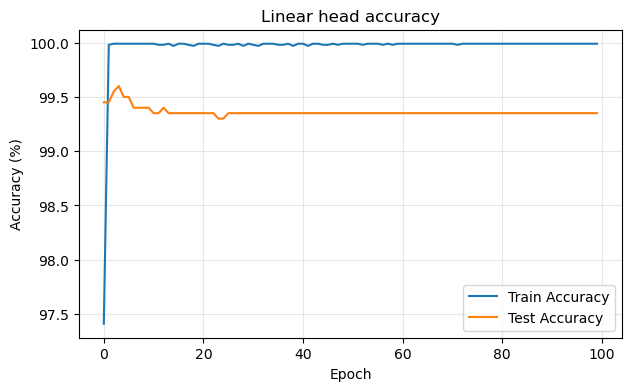

Best Task 0 test accuracy (linear): 99.60%
Final Task 0 test accuracy (linear): 99.35%


In [4]:
label_mapper_task0 = LabelMapper(task_classes=task0_classes)
task0_train_linear = seq_builder.get_task_dataset(
    task_id=0, train=True, transform=eval_transform, target_transform=label_mapper_task0
)
task0_test_linear = seq_builder.get_task_dataset(
    task_id=0, train=False, transform=eval_transform, target_transform=label_mapper_task0
)

task0_train_linear_loader = DataLoader(
    task0_train_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    **dataloader_kwargs,
)
task0_test_linear_loader = DataLoader(
    task0_test_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

linear_head = nn.Linear(feat_dim, len(task0_classes)).to(device)
linear_ckpt = ckpt("task0_linear_eval.pt")

if linear_ckpt.exists():
    payload = load_checkpoint(linear_ckpt, map_location=device)
    linear_head.load_state_dict(payload["linear_head"])
    linear_history = payload["history"]
    task0_best_test_accuracy = payload["best_test_acc"]
    print(f"Loaded checkpoint: {linear_ckpt}")
else:
    linear_history, task0_best_test_accuracy = train_linear_head(
        backbone=supcon_model.backbone,
        linear_head=linear_head,
        train_loader=task0_train_linear_loader,
        test_loader=task0_test_linear_loader,
        device=device,
        epochs=int(cfg.linear_eval.epochs),
        lr=float(cfg.linear_eval.lr),
        scheduler_milestones=list(cfg.linear_eval.milestones),
        scheduler_gamma=float(cfg.linear_eval.gamma),
        report_best=True,
    )
    save_checkpoint(
        linear_ckpt,
        {
            "linear_head": linear_head.state_dict(),
            "history": linear_history,
            "best_test_acc": task0_best_test_accuracy,
        },
    )
    print(f"Saved checkpoint: {linear_ckpt}")

plot_linear_history(linear_history, save_path=Path(cfg.outputs.root) / "imgs" / "linear_eval_accuracy.png")
print(f"Best Task 0 test accuracy (linear): {task0_best_test_accuracy:.2f}%")
print(f"Final Task 0 test accuracy (linear): {linear_history['test_acc'][-1]:.2f}%")


## 4.3.1 Fine-Tuning Naive

Task 0 | Epoch 01/30 | train_loss=0.1263
Task 0 | Epoch 02/30 | train_loss=0.0024
Task 0 | Epoch 03/30 | train_loss=0.0025
Task 0 | Epoch 04/30 | train_loss=0.0022
Task 0 | Epoch 05/30 | train_loss=0.0026
Task 0 | Epoch 06/30 | train_loss=0.0023
Task 0 | Epoch 07/30 | train_loss=0.0023
Task 0 | Epoch 08/30 | train_loss=0.0024
Task 0 | Epoch 09/30 | train_loss=0.0022
Task 0 | Epoch 10/30 | train_loss=0.0024
Task 0 | Epoch 11/30 | train_loss=0.0022
Task 0 | Epoch 12/30 | train_loss=0.0022
Task 0 | Epoch 13/30 | train_loss=0.0021
Task 0 | Epoch 14/30 | train_loss=0.0022
Task 0 | Epoch 15/30 | train_loss=0.0019
Task 0 | Epoch 16/30 | train_loss=0.0044
Task 0 | Epoch 17/30 | train_loss=0.0023
Task 0 | Epoch 18/30 | train_loss=0.0022
Task 0 | Epoch 19/30 | train_loss=0.0022
Task 0 | Epoch 20/30 | train_loss=0.0017
Task 0 | Epoch 21/30 | train_loss=0.0044
Task 0 | Epoch 22/30 | train_loss=0.0027
Task 0 | Epoch 23/30 | train_loss=0.0021
Task 0 | Epoch 24/30 | train_loss=0.0018
Task 0 | Epoch 2

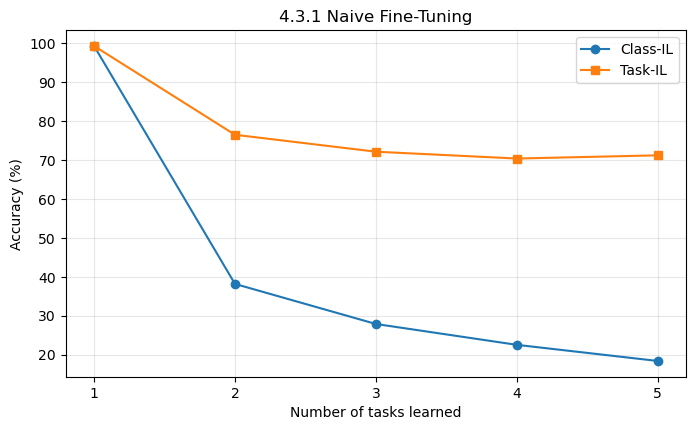

Naive final Class-IL: 18.42%
Naive final Task-IL: 71.22%


In [5]:
naive_ckpt = ckpt("naive_seq_cifar10.pt")

if naive_ckpt.exists():
    payload = load_checkpoint(naive_ckpt, map_location=device)
    naive_history = payload["history"]
    print(f"Loaded checkpoint: {naive_ckpt}")
else:
    naive_model, naive_history = train_naive_finetuning_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.finetuning.epochs_per_task),
        lr=float(cfg.finetuning.lr),
        momentum=float(cfg.finetuning.momentum),
        weight_decay=float(cfg.finetuning.weight_decay),
        verbose=True,
    )
    save_checkpoint(
        naive_ckpt,
        {
            "model": naive_model.state_dict(),
            "history": naive_history,
        },
    )
    print(f"Saved checkpoint: {naive_ckpt}")

plot_cl_metrics(naive_history, title="4.3.1 Naive Fine-Tuning", save_path=Path(cfg.outputs.root) / "imgs" / "naive_cl_metrics.png")
print(f"Naive final Class-IL: {naive_history['class_il'][-1]:.2f}%")
print(f"Naive final Task-IL: {naive_history['task_il'][-1]:.2f}%")


## 4.3.2 Elastic Weight Consolidation (EWC)

Task 0 | Epoch 01/30 | train_loss=0.1200
Task 0 | Epoch 02/30 | train_loss=0.0024
Task 0 | Epoch 03/30 | train_loss=0.0026
Task 0 | Epoch 04/30 | train_loss=0.0028
Task 0 | Epoch 05/30 | train_loss=0.0026
Task 0 | Epoch 06/30 | train_loss=0.0025
Task 0 | Epoch 07/30 | train_loss=0.0022
Task 0 | Epoch 08/30 | train_loss=0.0022
Task 0 | Epoch 09/30 | train_loss=0.0020
Task 0 | Epoch 10/30 | train_loss=0.0020
Task 0 | Epoch 11/30 | train_loss=0.0080
Task 0 | Epoch 12/30 | train_loss=0.0041
Task 0 | Epoch 13/30 | train_loss=0.0024
Task 0 | Epoch 14/30 | train_loss=0.0020
Task 0 | Epoch 15/30 | train_loss=0.0018
Task 0 | Epoch 16/30 | train_loss=0.0020
Task 0 | Epoch 17/30 | train_loss=0.0047
Task 0 | Epoch 18/30 | train_loss=0.0023
Task 0 | Epoch 19/30 | train_loss=0.0018
Task 0 | Epoch 20/30 | train_loss=0.0044
Task 0 | Epoch 21/30 | train_loss=0.0068
Task 0 | Epoch 22/30 | train_loss=0.0017
Task 0 | Epoch 23/30 | train_loss=0.0019
Task 0 | Epoch 24/30 | train_loss=0.0019
Task 0 | Epoch 2

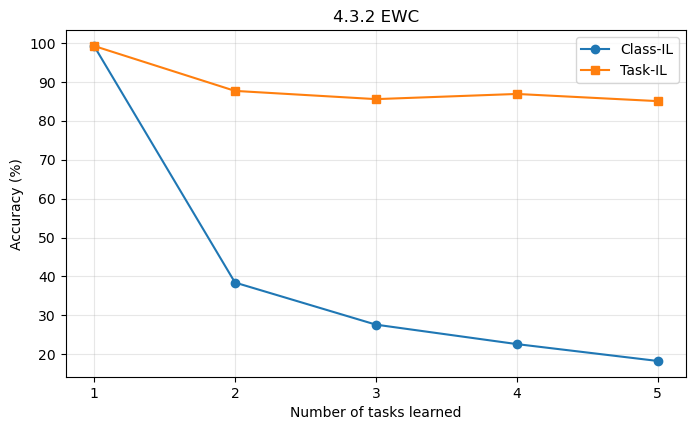

EWC final Class-IL: 18.26%
EWC final Task-IL: 85.07%


In [6]:
ewc_ckpt = ckpt("ewc_seq_cifar10.pt")

if ewc_ckpt.exists():
    payload = load_checkpoint(ewc_ckpt, map_location=device)
    ewc_history = payload["history"]
    print(f"Loaded checkpoint: {ewc_ckpt}")
else:
    ewc_model, ewc_history = train_ewc_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.ewc.epochs_per_task),
        lr=float(cfg.ewc.lr),
        momentum=float(cfg.ewc.momentum),
        weight_decay=float(cfg.ewc.weight_decay),
        ewc_lambda=float(cfg.ewc.lambda_ewc),
        fisher_max_batches=int(cfg.ewc.fisher_max_batches),
        verbose=True,
    )
    save_checkpoint(
        ewc_ckpt,
        {
            "model": ewc_model.state_dict(),
            "history": ewc_history,
        },
    )
    print(f"Saved checkpoint: {ewc_ckpt}")

plot_cl_metrics(ewc_history, title="4.3.2 EWC", save_path=Path(cfg.outputs.root) / "imgs" / "ewc_cl_metrics.png")
print(f"EWC final Class-IL: {ewc_history['class_il'][-1]:.2f}%")
print(f"EWC final Task-IL: {ewc_history['task_il'][-1]:.2f}%")


## 4.3.3 Learning without Forgetting (LwF)

In [1]:
lwf_ckpt = ckpt("lwf_seq_cifar10.pt")



if lwf_ckpt.exists():

    payload = load_checkpoint(lwf_ckpt, map_location=device)

    lwf_history = payload["history"]

    print(f"Loaded checkpoint: {lwf_ckpt}")

else:

    lwf_model, lwf_history = train_lwf_method(

        backbone=supcon_model.backbone,

        feat_dim=feat_dim,

        train_loaders=task_train_loaders,

        test_loaders=task_test_loaders,

        task_classes=seq_builder.task_classes,

        device=device,

        num_classes=len(CIFAR10_CLASSES),

        epochs_per_task=int(cfg.lwf.epochs_per_task),

        lr=float(cfg.lwf.lr),

        momentum=float(cfg.lwf.momentum),

        weight_decay=float(cfg.lwf.weight_decay),

        temperature=float(cfg.lwf.temperature),

        alpha=float(cfg.lwf.alpha),

        verbose=True,

    )

    save_checkpoint(

        lwf_ckpt,

        {

            "model": lwf_model.state_dict(),

            "history": lwf_history,

        },

    )

    print(f"Saved checkpoint: {lwf_ckpt}")



plot_cl_metrics(

    lwf_history,

    title="4.3.3 LwF",

    save_path=Path(cfg.outputs.root) / "imgs" / "lwf_cl_metrics.png",

)

print(f"LwF final Class-IL: {lwf_history['class_il'][-1]:.2f}%")

print(f"LwF final Task-IL: {lwf_history['task_il'][-1]:.2f}%")


NameError: name 'ckpt' is not defined

## 4.3.4 Contrastive Continual Learning (Co2L)

In [4]:
co2l_ckpt = ckpt("co2l_seq_cifar10.pt")

if co2l_ckpt.exists():
    payload = load_checkpoint(co2l_ckpt, map_location=device)
    co2l_history = payload["history"]
    print(f"Loaded checkpoint: {co2l_ckpt}")
else:
    co2l_model, co2l_history = train_co2l_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        proj_dim=int(cfg.supcon.proj_dim),
        buffer_size=int(cfg.data.buffer_size),
        lr=float(cfg.co2l.lr),
        momentum=float(cfg.co2l.momentum),
        weight_decay=float(cfg.co2l.weight_decay),
        temperature=float(cfg.co2l.temperature),
        kappa=float(cfg.co2l.kappa),
        kappa_star=float(cfg.co2l.kappa_star),
        lambda_ird=float(cfg.co2l.lambda_ird),
        warmup_epochs=int(cfg.co2l.warmup_epochs),
        epochs_task0=int(cfg.co2l.epochs_task0),
        epochs_per_task=int(cfg.co2l.epochs_per_task),
        eval_linear_epochs=int(cfg.co2l.eval_linear_epochs),
        eval_linear_lr=float(cfg.co2l.eval_linear_lr),
        eval_linear_milestones=list(cfg.co2l.eval_linear_milestones),
        eval_linear_gamma=float(cfg.co2l.eval_linear_gamma),
        seed=int(cfg.training.seed),
        verbose=True,
    )
    save_checkpoint(
        co2l_ckpt,
        {
            "model": co2l_model.state_dict(),
            "history": co2l_history,
        },
    )
    print(f"Saved checkpoint: {co2l_ckpt}")

plot_cl_metrics(
    co2l_history,
    title="4.3.4 Co2L",
    save_path=Path(cfg.outputs.root) / "imgs" / "co2l_cl_metrics.png",
)
print(f"Co2L final Class-IL: {co2l_history['class_il'][-1]:.2f}%")
print(f"Co2L final Task-IL: {co2l_history['task_il'][-1]:.2f}%")


Task 0 done (Co2L) | Class-IL=99.45% | Task-IL=99.45%


OutOfMemoryError: CUDA out of memory. Tried to allocate 114.00 MiB. GPU 0 has a total capacity of 7.62 GiB of which 46.50 MiB is free. Process 251946 has 4.09 GiB memory in use. Including non-PyTorch memory, this process has 3.46 GiB memory in use. Of the allocated memory 3.30 GiB is allocated by PyTorch, and 37.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## [Opcional] ER-ACE (Experience Replay with Asymmetric Cross-Entropy)

ER-ACE | Task 0 | Epoch 01/30 | loss=0.0490 | incoming=0.0490 | replay=0.0000
ER-ACE | Task 0 | Epoch 02/30 | loss=0.0014 | incoming=0.0014 | replay=0.0000
ER-ACE | Task 0 | Epoch 03/30 | loss=0.0010 | incoming=0.0010 | replay=0.0000
ER-ACE | Task 0 | Epoch 04/30 | loss=0.0009 | incoming=0.0009 | replay=0.0000
ER-ACE | Task 0 | Epoch 05/30 | loss=0.0007 | incoming=0.0007 | replay=0.0000
ER-ACE | Task 0 | Epoch 06/30 | loss=0.0005 | incoming=0.0005 | replay=0.0000
ER-ACE | Task 0 | Epoch 07/30 | loss=0.0024 | incoming=0.0024 | replay=0.0000
ER-ACE | Task 0 | Epoch 08/30 | loss=0.0025 | incoming=0.0025 | replay=0.0000
ER-ACE | Task 0 | Epoch 09/30 | loss=0.0009 | incoming=0.0009 | replay=0.0000
ER-ACE | Task 0 | Epoch 10/30 | loss=0.0005 | incoming=0.0005 | replay=0.0000
ER-ACE | Task 0 | Epoch 11/30 | loss=0.0003 | incoming=0.0003 | replay=0.0000
ER-ACE | Task 0 | Epoch 12/30 | loss=0.0004 | incoming=0.0004 | replay=0.0000
ER-ACE | Task 0 | Epoch 13/30 | loss=0.0003 | incoming=0.0003 | 

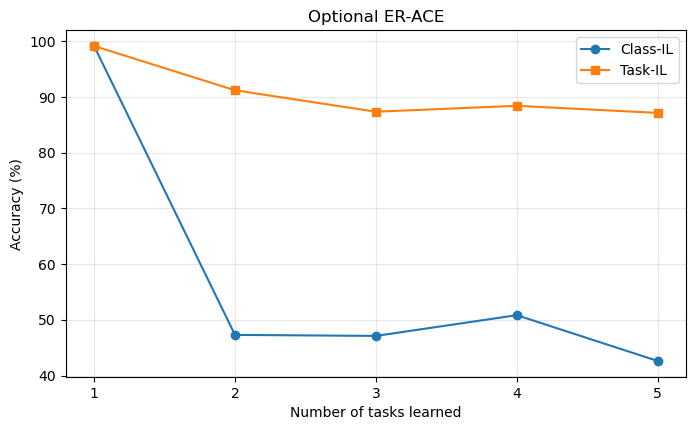

ER-ACE final Class-IL: 42.62%
ER-ACE final Task-IL: 87.14%


In [4]:
er_ace_ckpt = ckpt("er_ace_seq_cifar10.pt")

if er_ace_ckpt.exists():
    payload = load_checkpoint(er_ace_ckpt, map_location=device)
    er_ace_history = payload["history"]
    print(f"Loaded checkpoint: {er_ace_ckpt}")
else:
    er_ace_model, er_ace_history = train_er_ace_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.er_ace.epochs_per_task),
        lr=float(cfg.er_ace.lr),
        momentum=float(cfg.er_ace.momentum),
        weight_decay=float(cfg.er_ace.weight_decay),
        buffer_size=int(cfg.data.buffer_size),
        replay_batch_size=int(cfg.er_ace.replay_batch_size),
        incoming_weight=float(cfg.er_ace.incoming_weight),
        replay_weight=float(cfg.er_ace.replay_weight),
        seed=int(cfg.training.seed),
        verbose=True,
    )
    save_checkpoint(
        er_ace_ckpt,
        {
            "model": er_ace_model.state_dict(),
            "history": er_ace_history,
        },
    )
    print(f"Saved checkpoint: {er_ace_ckpt}")

plot_cl_metrics(
    er_ace_history,
    title="Optional ER-ACE",
    save_path=Path(cfg.outputs.root) / "imgs" / "er_ace_cl_metrics.png",
)
print(f"ER-ACE final Class-IL: {er_ace_history['class_il'][-1]:.2f}%")
print(f"ER-ACE final Task-IL: {er_ace_history['task_il'][-1]:.2f}%")


## 4.4 Comparativa final de metodos

In [ ]:
import csv
import matplotlib.pyplot as plt

method_histories = []

if "naive_history" in globals():
    method_histories.append(("Naive", naive_history))
if "ewc_history" in globals():
    method_histories.append(("EWC", ewc_history))
if "lwf_history" in globals():
    method_histories.append(("LwF", lwf_history))
if "co2l_history" in globals():
    method_histories.append(("Co2L", co2l_history))
if "er_ace_history" in globals():
    method_histories.append(("ER-ACE", er_ace_history))

if not method_histories:
    raise RuntimeError("No se encontraron historiales. Ejecuta primero las secciones de entrenamiento.")

summary = []
for method_name, hist in method_histories:
    class_il = float(hist["class_il"][-1])
    task_il = float(hist["task_il"][-1])
    summary.append({
        "method": method_name,
        "final_class_il": class_il,
        "final_task_il": task_il,
    })

summary = sorted(summary, key=lambda r: r["final_class_il"], reverse=True)

print("Comparativa final (ordenado por Class-IL):")
print("-" * 56)
print("{:<12} {:>12} {:>12}".format("Metodo", "Class-IL", "Task-IL"))
print("-" * 56)
for row in summary:
    print("{:<12} {:>11.2f}% {:>11.2f}%".format(row["method"], row["final_class_il"], row["final_task_il"]))

metrics_dir = Path(cfg.outputs.root) / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
csv_path = metrics_dir / "methods_comparison.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["method", "final_class_il", "final_task_il"])
    writer.writeheader()
    writer.writerows(summary)
print(f"Saved metrics table: {csv_path}")

methods = [r["method"] for r in summary]
class_vals = [r["final_class_il"] for r in summary]
task_vals = [r["final_task_il"] for r in summary]

x = range(len(methods))
w = 0.38
fig = plt.figure(figsize=(9, 4.8))
plt.bar([i - w / 2 for i in x], class_vals, width=w, label="Class-IL")
plt.bar([i + w / 2 for i in x], task_vals, width=w, label="Task-IL")
plt.xticks(list(x), methods)
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Comparativa final de metodos")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plot_path = Path(cfg.outputs.root) / "imgs" / "methods_comparison.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved comparison plot: {plot_path}")
